
--- PRIOR SENSITIVITY ANALYSIS (Mesafe Matrisi) ---
| Senaryo               | Posterior   |   KL_Divergence |   Wasserstein |   JS_Divergence |
|:----------------------|:------------|----------------:|--------------:|----------------:|
| Flat (1,1)            | Beta(39,13) |          0      |        0      |          0      |
| Zayıf (2,2)           | Beta(40,14) |          0.0135 |        0.0093 |          0.0033 |
| Bilgilendirici (15,5) | Beta(53,17) |          0.0315 |        0.0087 |          0.0069 |
| Güçlü (60,20)         | Beta(98,32) |          0.2954 |        0.0175 |          0.0461 |
| Uyuşmazlıklı (5,25)   | Beta(43,37) |          8.7928 |        0.2125 |          0.5992 |


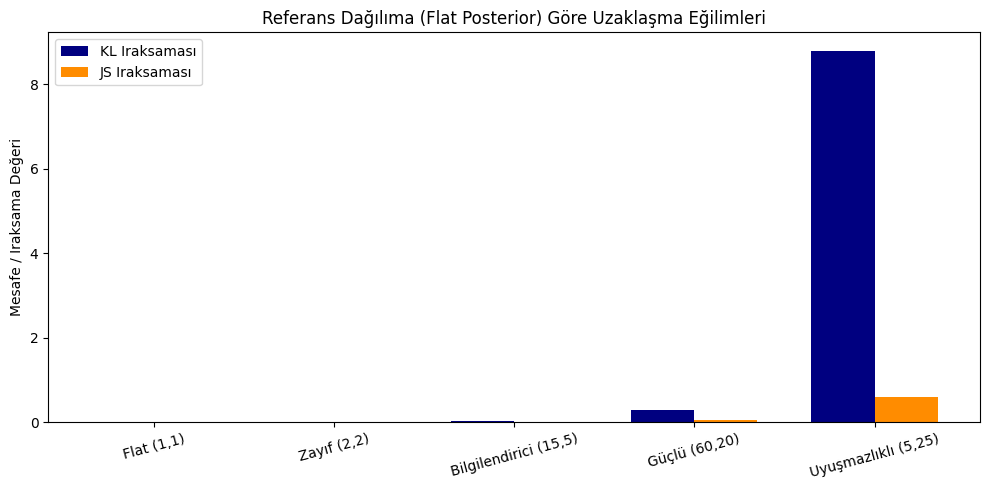

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.prior_sensitivity_lab.domain.beta_binomial import posterior_params
from src.prior_sensitivity_lab.distances.kl import kl_divergence
from src.prior_sensitivity_lab.distances.wasserstein import wasserstein_distance_beta
from src.prior_sensitivity_lab.distances.js import js_divergence_beta

# Sabit Veriler (Katılım Bankası Senaryosu)
n = 50
k = 38

# Referans Dağılım: Flat Önselin Posterior'u
ref_a, ref_b = 39, 13 

priors = {
    'Flat (1,1)': (1, 1),
    'Zayıf (2,2)': (2, 2),
    'Bilgilendirici (15,5)': (15, 5),
    'Güçlü (60,20)': (60, 20),
    'Uyuşmazlıklı (5,25)': (5, 25)
}

results = []

for name, (a_prior, b_prior) in priors.items():
    # Posterior hesapla
    a_post, b_post = posterior_params(a_prior, b_prior, k, n)
    
    # 3 Farklı Mesafe Metriğini Hesapla (Referans: Flat Posterior)
    kl_val = kl_divergence(ref_a, ref_b, a_post, b_post)
    wass_val = wasserstein_distance_beta(ref_a, ref_b, a_post, b_post)
    js_val = js_divergence_beta(ref_a, ref_b, a_post, b_post)
    
    results.append({
        "Senaryo": name,
        "Posterior": f"Beta({a_post},{b_post})",
        "KL_Divergence": round(kl_val, 4),
        "Wasserstein": round(wass_val, 4),
        "JS_Divergence": round(js_val, 4)
    })

# DataFrame oluştur ve terminale yazdır
df_results = pd.DataFrame(results)
print("\n--- PRIOR SENSITIVITY ANALYSIS (Mesafe Matrisi) ---")
print(df_results.to_markdown(index=False))

# (Opsiyonel) Görselleştirme: Metriklerin Büyüme Hızını Kıyaslama
# Sadece KL ve JS'yi aynı grafikte göstermek (Wasserstein ölçeği çok küçük olduğu için ayrı çizilebilir)
plt.figure(figsize=(10, 5))
x = np.arange(len(df_results))
width = 0.35

plt.bar(x - width/2, df_results['KL_Divergence'], width, label='KL Iraksaması', color='navy')
plt.bar(x + width/2, df_results['JS_Divergence'], width, label='JS Iraksaması', color='darkorange')

plt.xticks(x, df_results['Senaryo'], rotation=15)
plt.ylabel('Mesafe / Iraksama Değeri')
plt.title('Referans Dağılıma (Flat Posterior) Göre Uzaklaşma Eğilimleri')
plt.legend()
plt.tight_layout()
plt.show()